In [14]:
# =============================================================================
# EVALUATE MULTIPLE XGBOOST MODEL OUTPUTS
# =============================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    log_loss,
    mean_squared_error,
    mean_absolute_error,
    precision_score
)

# Paths

BASE_DIR = Path("C:\\Users\\EmmaGolub\\Desktop\\MRoS_local\\mros-precipitation-phase-product-prototype")
ML_DIR = BASE_DIR / "ML_pipeline" / "model_artifacts"

# List folders to evaluate
model_folders = [
    "withIDW",
    "withKriging",
    "withIDW_v3",
    "withKriging_v3",    
    "withIDW_v4",
    "withKriging_v4",
]

In [ ]:
# =============================================================================
# HELPER FUNCTIONS for EVALUATION 
# =============================================================================

def inspect_output_schema(df, model_name):
    print("\n=================================================")
    print(f"Inspecting schema for: {model_name}")
    print("-------------------------------------------------")
    print("Columns:")
    print(list(df.columns))
    print("\nDtypes:")
    print(df.dtypes)
    print("=================================================\n")

def standardize_prediction_df(df):
    """
    Attempts to standardize prediction dataframe across
    different ML output versions.
    Returns:
        y_true, y_pred, y_prob (np arrays)
    """

    # --------------------------------------------------
    # 1. TRUE LABEL COLUMN
    # --------------------------------------------------
    possible_truth_cols = ["phase", "phase_full", "y_true", "label"]
    truth_col = next((c for c in possible_truth_cols if c in df.columns), None)

    if truth_col is None:
        raise ValueError("Could not find ground truth column.")

    # --------------------------------------------------
    # 2. PREDICTED CLASS COLUMN
    # --------------------------------------------------
    possible_pred_cols = ["prediction", "pred", "y_pred", "pred_class"]
    pred_col = next((c for c in possible_pred_cols if c in df.columns), None)

    if pred_col is None:
        print("No explicit prediction column found — deriving from probabilities.")
    
    # --------------------------------------------------
    # 3. PROBABILITY COLUMNS
    # --------------------------------------------------
    prob_cols = [c for c in df.columns if c.startswith("p_")]

    if len(prob_cols) == 0:
        raise ValueError("No probability columns found (p_*)")

    # Sort probability columns to keep class order consistent
    prob_cols = sorted(prob_cols)

    # --------------------------------------------------
    # BUILD ARRAYS
    # --------------------------------------------------

    y_true = df[truth_col].values
    y_prob = df[prob_cols].values

    if pred_col:
        y_pred = df[pred_col].values
    else:
        # derive prediction from highest probability
        y_pred = np.argmax(y_prob, axis=1)

    return y_true, y_pred, y_prob, prob_cols

# ---------------------------------------------------------------------
# METRIC FUNCTION
# ---------------------------------------------------------------------

def evaluate_model(model_dir):

    print("\n======================================================")
    print("Evaluating:", model_dir.name)
    print("======================================================")

    pred_path = model_dir / "test_predictions.parquet"
    df = pd.read_parquet(pred_path)

    inspect_output_schema(df, model_dir.name)

    y_true, y_pred, y_prob, prob_cols = standardize_prediction_df(df)

    # ----------------------------
    # METRICS
    # ----------------------------

    from sklearn.metrics import (
        accuracy_score,
        f1_score,
        log_loss,
        mean_squared_error,
        mean_absolute_error
    )

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    ll = log_loss(y_true, y_prob)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f"  Probability columns used: {prob_cols}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Macro F1:  {macro_f1:.4f}")
    print(f"  Log Loss:  {ll:.4f}")
    print(f"  RMSE:      {rmse:.4f}")
    print(f"  MAE:       {mae:.4f}")

    return {
        "model": model_dir.name,
        "accuracy": acc,
        "macro_f1": macro_f1,
        "log_loss": ll,
        "rmse": rmse,
        "mae": mae
    }


# ---------------------------------------------------------------------
# LOOP THROUGH MODELS
# ---------------------------------------------------------------------

results = []

for folder in model_folders:
    model_dir = ML_DIR / folder
    if model_dir.exists():
        results.append(evaluate_model(model_dir))
    else:
        print(f"Skipping {folder} (not found)")

# ---------------------------------------------------------------------
# SUMMARY TABLE
# ---------------------------------------------------------------------

results_df = pd.DataFrame(results)
print("\n\n=== SUMMARY TABLE ===")
print(results_df.sort_values("macro_f1", ascending=False))


Evaluating: withIDW

Inspecting schema for: withIDW
-------------------------------------------------
Columns:
['time', 'x', 'y', 'phase', 'pred', 'p_snow', 'p_mix', 'p_rain', 'block_id']

Dtypes:
time        datetime64[ns]
x                  float64
y                  float64
phase              float64
pred                 int64
p_snow             float32
p_mix              float32
p_rain             float32
block_id            object
dtype: object

  Probability columns used: ['p_mix', 'p_rain', 'p_snow']
  Accuracy:  0.7267
  Macro F1:  0.7147
  Log Loss:  3.5638
  RMSE:      0.5329
  MAE:       0.2768

Evaluating: withKriging

Inspecting schema for: withKriging
-------------------------------------------------
Columns:
['time', 'x', 'y', 'phase', 'pred', 'p_snow', 'p_mix', 'p_rain', 'block_id']

Dtypes:
time        datetime64[ns]
x                  float64
y                  float64
phase              float64
pred                 int64
p_snow             float32
p_mix             

c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


  Probability columns used: ['p_mix', 'p_rain', 'p_snow']
  Accuracy:  0.4805
  Macro F1:  0.3789
  Log Loss:  1.3623
  RMSE:      1.1403
  MAE:       0.7798

Evaluating: withKriging_v3

Inspecting schema for: withKriging_v3
-------------------------------------------------
Columns:
['time', 'x', 'y', 'phase_binary', 'phase_full', 'pred_phase_abst', 'p_rain', 'p_snow', 'p_mix', 'max_prob', 'block_id']

Dtypes:
time               datetime64[ns]
x                         float64
y                         float64
phase_binary              float64
phase_full                float64
pred_phase_abst             int64
p_rain                    float32
p_snow                    float32
p_mix                     float32
max_prob                  float32
block_id                   object
dtype: object

No explicit prediction column found — deriving from probabilities.


c:\Users\EmmaGolub\Desktop\MRoS_local\venv\Lib\site-packages\sklearn\metrics\_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


  Probability columns used: ['p_mix', 'p_rain', 'p_snow']
  Accuracy:  0.4652
  Macro F1:  0.3681
  Log Loss:  1.1869
  RMSE:      1.1938
  MAE:       0.8316

Evaluating: withIDW_v4

Inspecting schema for: withIDW_v4
-------------------------------------------------
Columns:
['time', 'x', 'y', 'phase', 'prediction', 'p_snow', 'p_rain', 'p_mix', 'max_prob', 'entropy', 'block_id']

Dtypes:
time          datetime64[ns]
x                    float64
y                    float64
phase                float64
prediction             int64
p_snow               float32
p_rain               float32
p_mix                float32
max_prob             float32
entropy              float32
block_id              object
dtype: object

  Probability columns used: ['p_mix', 'p_rain', 'p_snow']
  Accuracy:  0.5840
  Macro F1:  0.5204
  Log Loss:  1.2897
  RMSE:      0.9683
  MAE:       0.5898

Evaluating: withKriging_v4

Inspecting schema for: withKriging_v4
-------------------------------------------------


In [ ]:
# =============================================================================
# FREEZING DIAGNOSTICS
#   - Rain vs Snow only accuracy
#   - Mix recall
# =============================================================================

FREEZE_MIN = 0.0   # °C
FREEZE_MAX = 4.0   # °C


# --------------------------------------------------
# Helper: Find parquet file by keyword
# --------------------------------------------------

def find_parquet_file(model_dir, keyword):
    files = list(model_dir.glob(f"*{keyword}*.parquet"))
    if len(files) == 0:
        raise FileNotFoundError(f"No parquet file containing '{keyword}' found.")
    if len(files) > 1:
        print(f"Multiple matches for '{keyword}', using first:", files[0].name)
    return files[0]


# --------------------------------------------------
# Main Evaluation Function
# --------------------------------------------------

def evaluate_freezing_metrics(model_dir):

    print("\n======================================================")
    print(f"Freezing Diagnostics: {model_dir.name}")
    print("======================================================")

    # --------------------------------------------------
    # 1Detect files automatically
    # --------------------------------------------------
    pred_file = find_parquet_file(model_dir, "prediction")
    X_file = find_parquet_file(model_dir, "X_test")

    df_pred = pd.read_parquet(pred_file)
    df_X = pd.read_parquet(X_file)

    if len(df_pred) != len(df_X):
        raise ValueError("Row mismatch between prediction file and X_test file.")

    # --------------------------------------------------
    # Detect wet bulb column automatically
    # --------------------------------------------------
    wetbulb_candidates = [c for c in df_X.columns if "wet" in c.lower()]

    if len(wetbulb_candidates) == 0:
        raise ValueError("No wet-bulb-like column found in X file.")

    wet_col = wetbulb_candidates[0]
    print("Using wet bulb column:", wet_col)

    # Merge wet bulb
    df = df_pred.copy()
    df["temp_wet"] = df_X[wet_col].values

    # --------------------------------------------------
    # Detect truth column
    # --------------------------------------------------
    truth_candidates = ["phase", "phase_full", "label", "y_true"]
    truth_col = next((c for c in truth_candidates if c in df.columns), None)

    if truth_col is None:
        raise ValueError("Ground truth column not found.")

    print("Using truth column:", truth_col)

    # --------------------------------------------------
    # Detect probability columns
    # --------------------------------------------------
    prob_cols = sorted([c for c in df.columns if c.startswith("p_")])

    if len(prob_cols) == 0:
        raise ValueError("No probability columns (p_*) found.")

    print("Probability columns:", prob_cols)

    y_prob = df[prob_cols].values
    y_true = df[truth_col].values

    # Derive predicted class
    y_pred = np.argmax(y_prob, axis=1)

    df["y_true"] = y_true
    df["y_pred"] = y_pred

    # --------------------------------------------------
    # Apply freezing window
    # --------------------------------------------------
    df_freeze = df[
        (df["temp_wet"] >= FREEZE_MIN) &
        (df["temp_wet"] <= FREEZE_MAX)
    ].copy()

    n_total = len(df)
    n_freeze = len(df_freeze)

    print(f"Total samples:     {n_total}")
    print(f"Freezing samples:  {n_freeze}")
    print(f"Freezing fraction: {n_freeze/n_total:.3f}")

    if n_freeze == 0:
        print("No samples in freezing window.")
        return None

    # --------------------------------------------------
    # Rain vs Snow Only
    # --------------------------------------------------
    df_rs = df_freeze[df_freeze["y_true"].isin([0, 1])].copy()

    if len(df_rs) > 0:
        rs_acc = accuracy_score(df_rs["y_true"], df_rs["y_pred"])
        rs_f1 = f1_score(df_rs["y_true"], df_rs["y_pred"], average="macro")

        print("\n--- Rain vs Snow Only (Freezing) ---")
        print(f"Samples:  {len(df_rs)}")
        print(f"Accuracy: {rs_acc:.4f}")
        print(f"Macro F1: {rs_f1:.4f}")
    else:
        rs_acc = np.nan
        rs_f1 = np.nan
        print("\nNo rain/snow samples in freezing window.")

    # --------------------------------------------------
    # Mix Recall (if multiclass)
    # --------------------------------------------------
    if len(prob_cols) >= 3:  # implies multiclass
        df_mix = df_freeze[df_freeze["y_true"] == 2]

        if len(df_mix) > 0:
            mix_recall = recall_score(
                df_mix["y_true"],
                df_mix["y_pred"],
                labels=[2],
                average=None
            )[0]

            print("\n--- Mix Recall (Freezing) ---")
            print(f"True mix samples: {len(df_mix)}")
            print(f"Mix recall: {mix_recall:.4f}")
        else:
            mix_recall = np.nan
            print("\nNo true mix samples in freezing window.")
    else:
        mix_recall = np.nan
        print("\nBinary model detected — no mix class.")

    return {
        "model": model_dir.name,
        "n_freezing": n_freeze,
        "rs_accuracy_freeze": rs_acc,
        "rs_macro_f1_freeze": rs_f1,
        "mix_recall_freeze": mix_recall
    }


# =============================================================================
# LOOP THROUGH MODELS
# =============================================================================

freeze_results = []

for folder in model_folders:
    model_dir = ML_DIR / folder
    if model_dir.exists():
        out = evaluate_freezing_metrics(model_dir)
        if out:
            freeze_results.append(out)

freeze_df = pd.DataFrame(freeze_results)

print("\n================ FREEZING SUMMARY ================")
print(freeze_df.sort_values("rs_macro_f1_freeze", ascending=False))


Freezing Diagnostics: withIDW
Multiple matches for 'prediction', using first: test_predictions.parquet
Multiple matches for 'X_test', using first: X_test.parquet
Using wet bulb column: temp_wet
Using truth column: phase
Probability columns: ['p_mix', 'p_rain', 'p_snow']
Total samples:     3925329
Freezing samples:  1203215
Freezing fraction: 0.307

--- Rain vs Snow Only (Freezing) ---
Samples:  1000664
Accuracy: 0.1601
Macro F1: 0.1225

--- Mix Recall (Freezing) ---
True mix samples: 202551
Mix recall: 0.0181

Freezing Diagnostics: withKriging
Multiple matches for 'prediction', using first: test_predictions.parquet
Multiple matches for 'X_test', using first: X_test.parquet
Using wet bulb column: temp_wet
Using truth column: phase
Probability columns: ['p_mix', 'p_rain', 'p_snow']
Total samples:     3919579
Freezing samples:  1536820
Freezing fraction: 0.392

--- Rain vs Snow Only (Freezing) ---
Samples:  1232161
Accuracy: 0.2445
Macro F1: 0.1810

--- Mix Recall (Freezing) ---
True mix

## Explaining these results

### High Level
#### 🔴 Original models
- High global accuracy
- Collapse near freezing
- Almost never predict mix
- Likely overconfident
- These models look good in aggregate but fail where it matters physically.

#### 🟡 v3 models
- Major improvement in transition handling
- High mix recall (~0.5+)
- Moderate rain/snow separation
- These models learned transitional physics but may slightly overuse mix.

#### 🟢 v4 models
- Best rain/snow separation in freezing regime
- Slightly lower mix recall
- Best overall balance
- Kriging_v4 currently looks strongest in transition zone.

### More detail:
The original models completely fail in the transition regime!
- They are almost never predicting mix.
- They are barely separating rain vs snow near 0°C.
- They likely default to a dominant class with high confidence.
- This explains why global accuracy looked “good” for withIDW earlier — it was probably doing fine in clear snow and clear rain regimes but collapsing near freezing.

v3 is the first version that actually learns a transitional phase.
The fact that mix recall reaches 0.56 in v3 means the model is not inventing mix — it's responding to transitional features.

Rain vs Snow (freeze)
- v3 IDW: 0.414
- v4 IDW: 0.420 (slight improvement)
- v3 Kriging: 0.457
- v4 Kriging: 0.470 (improvement)
- So v4 improves binary separation in freezing regime.

Mix Recall
- v3 IDW: 0.517
- v4 IDW: 0.460 (drops)
- v3 Kriging: 0.562
- v4 Kriging: 0.409 (drops)
- So v4 reduces mix recall.

v3 may have been slightly overpredicting mix.
v4 trades some mix recall for improved rain/snow separation.

Across all versions:
- Kriging consistently beats IDW in freezing regime.
- The smoother spatial structure from kriging improves transition discrimination.

In [ ]:
# =============================================================================
# MIX PRECISION (0–4°C WET BULB)
# =============================================================================

FREEZE_MIN = 0.0
FREEZE_MAX = 4.0


def mix_precision_freezing(model_dir):

    print("\n======================================================")
    print(f"Mix Precision (0-4°C): {model_dir.name}")
    print("======================================================")

    pred_file = find_parquet_file(model_dir, "prediction")
    X_file = find_parquet_file(model_dir, "X_test")

    df_pred = pd.read_parquet(pred_file)
    df_X = pd.read_parquet(X_file)

    # Detect wet bulb column
    wet_col = [c for c in df_X.columns if "wet" in c.lower()][0]

    df = df_pred.copy()
    df["temp_wet"] = df_X[wet_col].values

    # Detect truth column
    truth_col = next(c for c in ["phase", "phase_full"] if c in df.columns)

    # Detect probability columns
    prob_cols = sorted([c for c in df.columns if c.startswith("p_")])

    y_prob = df[prob_cols].values
    df["y_pred"] = np.argmax(y_prob, axis=1)
    df["y_true"] = df[truth_col].values

    # Apply 0–4°C window
    df_freeze = df[
        (df["temp_wet"] >= FREEZE_MIN) &
        (df["temp_wet"] <= FREEZE_MAX)
    ].copy()

    if 2 not in df_freeze["y_pred"].unique():
        print("No mix predictions in window.")
        return None

    mix_precision = precision_score(
        df_freeze["y_true"],
        df_freeze["y_pred"],
        labels=[2],
        average=None
    )[0]

    print(f"Samples in window: {len(df_freeze)}")
    print(f"Mix precision (0–4°C): {mix_precision:.4f}")

    return mix_precision

# =============================================================================
# LOOP THROUGH MODELS
# =============================================================================

freeze_precision = []

for folder in model_folders:
    model_dir = ML_DIR / folder
    if model_dir.exists():
        out = mix_precision_freezing(model_dir)
        if out:
            freeze_precision.append(out)

freeze_precision_df = pd.DataFrame(freeze_precision, columns=["mix_precision_freeze"])

print("\n================ FREEZING PRECISION ================")
print(freeze_precision_df.sort_values("mix_precision_freeze", ascending=False))


Mix Precision (0–4°C): withIDW
Multiple matches for 'prediction', using first: test_predictions.parquet
Multiple matches for 'X_test', using first: X_test.parquet
Samples in window: 1203215
Mix precision (0–4°C): 0.0110

Mix Precision (0–4°C): withKriging
Multiple matches for 'prediction', using first: test_predictions.parquet
Multiple matches for 'X_test', using first: X_test.parquet
Samples in window: 1536820
Mix precision (0–4°C): 0.0669

Mix Precision (0–4°C): withIDW_v3
Samples in window: 1203215
Mix precision (0–4°C): 0.3953

Mix Precision (0–4°C): withKriging_v3
Samples in window: 1536820
Mix precision (0–4°C): 0.3369

Mix Precision (0–4°C): withIDW_v4
Multiple matches for 'prediction', using first: test_predictions.parquet
Multiple matches for 'X_test', using first: X_test.parquet
Samples in window: 1203215
Mix precision (0–4°C): 0.3742

Mix Precision (0–4°C): withKriging_v4
Multiple matches for 'prediction', using first: test_predictions.parquet
Multiple matches for 'X_test',

## Explaining freezing precision

### Big picture
- Early models failed exactly where the physics is hardest
- v3 meaningfully fixed that
- v4 sharpened classification boundaries
- Kriging improves freezing-zone rain/snow discrimination
- Mix is now a learned, structured regime — not noise

#### Early models
- When they predicted mix, they were almost always wrong
- And they almost never predicted mix anyway
- These models effectively collapsed mix into rain/snow
- Were not true multiclass models in practice — mix was suppressed

#### v3 models
- 33–40% of predicted mix events are correct
- And 50–56% of true mix events are captured
- That’s a real, functioning transition classifier
- v3 pipeline changes allowed the model to meaningfully represent the transitional regime

#### v4 models
- Compared to v3:
-  Precision drops slightly
-  Recall drops more noticeably
- v4 became more conservative with mix
- It predicts mix less often and misses more true mix events
- Rain/Snow accuracy improved in v4
- So v4 trades some mix capture for better binary separation


Multiple matches for 'prediction', using first: test_predictions.parquet
Multiple matches for 'X_test', using first: X_test.parquet


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_27256\876775711.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("wb_bin").apply(
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_27256\876775711.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby("wb_bin").apply(


Multiple matches for 'prediction', using first: test_predictions.parquet
Multiple matches for 'X_test', using first: X_test.parquet


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_27256\876775711.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("wb_bin").apply(
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_27256\876775711.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby("wb_bin").apply(
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_27256\876775711.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False

Multiple matches for 'prediction', using first: test_predictions.parquet
Multiple matches for 'X_test', using first: X_test.parquet


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_27256\876775711.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("wb_bin").apply(
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_27256\876775711.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby("wb_bin").apply(


Multiple matches for 'prediction', using first: test_predictions.parquet
Multiple matches for 'X_test', using first: X_test.parquet


C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_27256\876775711.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("wb_bin").apply(
C:\Users\EmmaGolub\AppData\Local\Temp\ipykernel_27256\876775711.py:27: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby("wb_bin").apply(


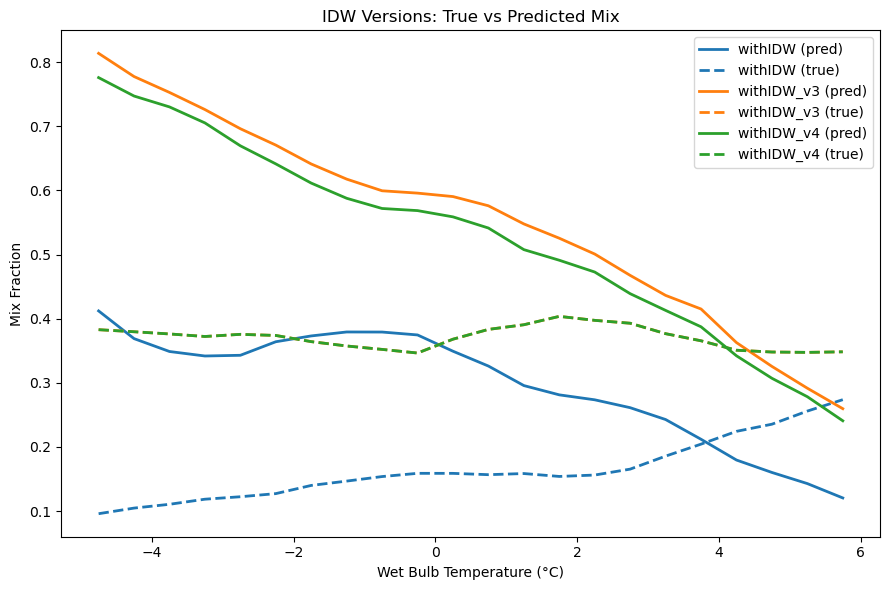

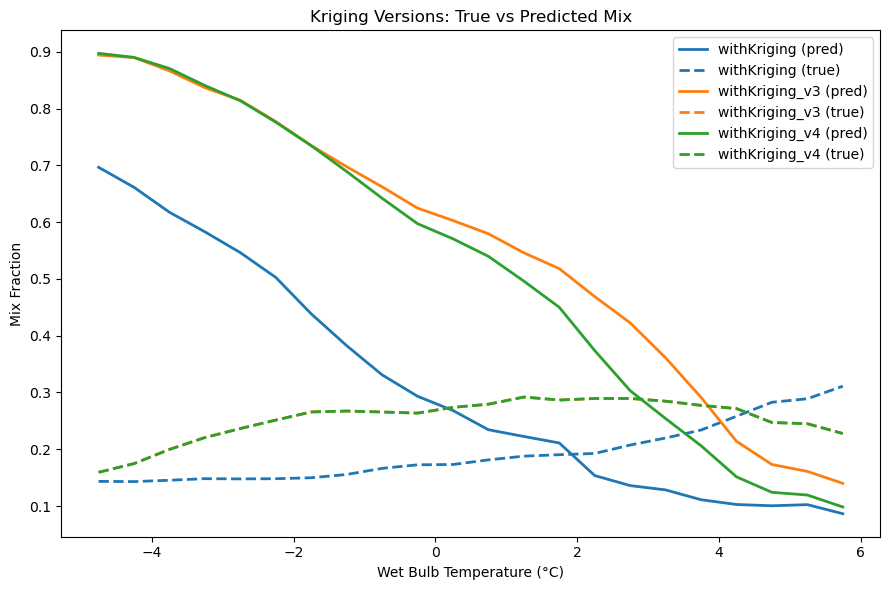

In [15]:
# =============================================================================
# MIX FREQUENCY PLOTS
# =============================================================================

def compute_mix_summary(model_dir, bin_width=0.5):

    pred_file = find_parquet_file(model_dir, "prediction")
    X_file = find_parquet_file(model_dir, "X_test")

    df_pred = pd.read_parquet(pred_file)
    df_X = pd.read_parquet(X_file)

    wet_col = [c for c in df_X.columns if "wet" in c.lower()][0]

    df = df_pred.copy()
    df["temp_wet"] = df_X[wet_col].values

    truth_col = next(c for c in ["phase", "phase_full"] if c in df.columns)
    prob_cols = sorted([c for c in df.columns if c.startswith("p_")])

    df["y_pred"] = np.argmax(df[prob_cols].values, axis=1)
    df["y_true"] = df[truth_col].values

    bins = np.arange(-5, 6.5, bin_width)
    df["wb_bin"] = pd.cut(df["temp_wet"], bins=bins)

    summary = df.groupby("wb_bin").apply(
        lambda g: pd.Series({
            "true_mix_frac": np.mean(g["y_true"] == 2),
            "pred_mix_frac": np.mean(g["y_pred"] == 2),
        })
    ).reset_index()

    summary["wb_center"] = summary["wb_bin"].apply(lambda x: x.mid)
    summary["model"] = model_dir.name

    return summary


# --------------------------------------------------
# Compute summaries
# --------------------------------------------------

all_summaries = []

for folder in model_folders:
    model_dir = ML_DIR / folder
    if model_dir.exists():
        all_summaries.append(compute_mix_summary(model_dir))

mix_freq_df = pd.concat(all_summaries, ignore_index=True)


# =============================================================================
# MIX FREQUENCY PLOTS
# =============================================================================
from itertools import cycle


def plot_group(group_keyword, title):

    plt.figure(figsize=(9,6))

    models = sorted(
        [m for m in mix_freq_df["model"].unique() if group_keyword in m]
    )

    color_cycle = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])

    for model_name in models:

        color = next(color_cycle)
        subset = mix_freq_df[mix_freq_df["model"] == model_name]

        # Predicted (solid)
        plt.plot(
            subset["wb_center"],
            subset["pred_mix_frac"],
            color=color,
            linewidth=2,
            label=f"{model_name} (pred)"
        )

        # True (dashed, same color)
        plt.plot(
            subset["wb_center"],
            subset["true_mix_frac"],
            color=color,
            linestyle="--",
            linewidth=2,
            label=f"{model_name} (true)"
        )

    plt.xlabel("Wet Bulb Temperature (°C)")
    plt.ylabel("Mix Fraction")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# Plot IDW Versions
# --------------------------------------------------

plot_group("IDW", "IDW Versions: True vs Predicted Mix")


# --------------------------------------------------
# Plot Kriging Versions
# --------------------------------------------------

plot_group("Kriging", "Kriging Versions: True vs Predicted Mix")

## Explaining Freq vs Wet Bulb

### Key finding: No version learns a peaked mix regime centered near freezing. All versions learn a smooth monotonic cold-to-warm gradient.A smooth uncertainty gradient tied to cold-to-warm transition rather than a sharply peaked thermodynamic boundary regime.

### Original (withIDW, withKriging)
- Predicted mix highest at coldest wet-bulb bins; decreases monotonically with warming (physically inverted structure).
- Mix effectively suppressed as a meaningful class (very low recall and precision).
- Poor rain/snow discrimination in freezing regime despite decent global accuracy.
- Behaves like a brittle binary classifier; fails in the thermodynamically critical transition zone.

### v3 (withIDW_v3, withKriging_v3)
- Major structural shift: mix becomes an actively learned, high-recall class (~50–56%).
- Predicted mix curve smooth and structured but still monotonic (overpredicts in cold bins).
- Substantial improvement in freezing rain/snow separation.
- Mix functions more as broad transition/uncertainty regime than sharply peaked thermodynamic phase.

### v4 (withIDW_v4, withKriging_v4)
- Refines v3: tighter decision boundaries, improved rain/snow accuracy in freezing window.
- Slight reduction in mix recall and precision (more conservative mix use).
- Cold-bin overprediction reduced but monotonic structure persists.
- Represents better-calibrated transition model, though still not thermodynamically peaked near 0–2°C.